# Inspect Precomputed CDR Metrics

This notebook checks parquet files generated by `preprocess/precompute_decoy_metrics.py` under `cdr-data/metrics_precomputed`.

It focuses on quick validation:
- which source files exist
- row counts and columns
- identity key uniqueness: `target_id + source + seed + sample`
- target-level CDR counts
- metric ranges, NaN rates, and success rates
- suspicious rows such as high missing backbone atom counts

In [1]:
from pathlib import Path
import math
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/cdr_scoring_matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

METRICS_ROOT = Path("/home/sujin/projects/cdr-scoring/cdr-data/metrics_precomputed_boltz2_s10n10_combined")
METRICS_ROOT

PosixPath('/home/sujin/projects/cdr-scoring/cdr-data/metrics_precomputed_boltz2_s10n10_combined')

In [2]:
parquet_files = sorted(METRICS_ROOT.glob("*/*/*.parquet"))
files_df = pd.DataFrame({
    "source": [p.parts[-3] for p in parquet_files],
    "group": [p.parts[-2] for p in parquet_files],
    "file": [p.name for p in parquet_files],
    "path": [str(p) for p in parquet_files],
    "size_mb": [p.stat().st_size / 1024**2 for p in parquet_files],
})
display(files_df.sort_values(["source", "group", "file"]))

if files_df.empty:
    raise FileNotFoundError(f"No parquet files found under {METRICS_ROOT}")

,source,group,file,path,size_mb
0,Boltz2_s10n10,metrics,dockq_metrics.parquet,/home/sujin/projects/cdr-scoring/cdr-data/metrics_precomputed_boltz2_s10n10_combined/Boltz2_s10n10/metrics/dockq_metrics.parquet,7.427404
1,Boltz2_s10n10,metrics,interface_metrics.parquet,/home/sujin/projects/cdr-scoring/cdr-data/metrics_precomputed_boltz2_s10n10_combined/Boltz2_s10n10/metrics/interface_metrics.parquet,8.861305
2,Boltz2_s10n10,metrics,loop_metrics.parquet,/home/sujin/projects/cdr-scoring/cdr-data/metrics_precomputed_boltz2_s10n10_combined/Boltz2_s10n10/metrics/loop_metrics.parquet,27.363400
3,Boltz2_s10n10,targets,target_metrics.parquet,/home/sujin/projects/cdr-scoring/cdr-data/metrics_precomputed_boltz2_s10n10_combined/Boltz2_s10n10/targets/target_metrics.parquet,0.079146
4,combined,metrics,dockq_metrics.parquet,/home/sujin/projects/cdr-scoring/cdr-data/metrics_precomputed_boltz2_s10n10_combined/combined/metrics/dockq_metrics.parquet,7.427404
5,combined,metrics,interface_metrics.parquet,/home/sujin/projects/cdr-scoring/cdr-data/metrics_precomputed_boltz2_s10n10_combined/combined/metrics/interface_metrics.parquet,8.861305
6,combined,metrics,loop_metrics.parquet,/home/sujin/projects/cdr-scoring/cdr-data/metrics_precomputed_boltz2_s10n10_combined/combined/metrics/loop_metrics.parquet,27.363400
7,combined,targets,target_metrics.parquet,/home/sujin/projects/cdr-scoring/cdr-data/metrics_precomputed_boltz2_s10n10_combined/combined/targets/target_metrics.parquet,0.079146


In [3]:
def read_source_table(source: str, group: str, filename: str) -> pd.DataFrame:
    path = METRICS_ROOT / source / group / filename
    if not path.exists():
        return pd.DataFrame()
    return pd.read_parquet(path)

sources = sorted(files_df["source"].unique())
tables = {}
for source in sources:
    tables[(source, "targets")] = read_source_table(source, "targets", "target_metrics.parquet")
    tables[(source, "loop")] = read_source_table(source, "metrics", "loop_metrics.parquet")
    tables[(source, "interface")] = read_source_table(source, "metrics", "interface_metrics.parquet")
    tables[(source, "dockq")] = read_source_table(source, "metrics", "dockq_metrics.parquet")

overview_rows = []
for (source, table_name), df in tables.items():
    if df.empty:
        continue
    overview_rows.append({
        "source": source,
        "table": table_name,
        "rows": len(df),
        "columns": len(df.columns),
        "targets": df["target_id"].nunique() if "target_id" in df else np.nan,
        "decoys": len(df[["target_id", "source", "seed", "sample"]].drop_duplicates()) if {"target_id", "source", "seed", "sample"}.issubset(df.columns) else np.nan,
    })

overview = pd.DataFrame(overview_rows).sort_values(["source", "table"])
display(overview)

,source,table,rows,columns,targets,decoys
3,Boltz2_s10n10,dockq,199000,14,1990,199000.0
2,Boltz2_s10n10,interface,199000,20,1990,199000.0
1,Boltz2_s10n10,loop,199000,26,1990,199000.0
0,Boltz2_s10n10,targets,1990,14,1990,NaN
7,combined,dockq,199000,14,1990,199000.0
6,combined,interface,199000,20,1990,199000.0
5,combined,loop,199000,26,1990,199000.0
4,combined,targets,1990,14,1990,NaN


## Inspect One Source

Change `SOURCE` below to inspect a specific source in detail.

In [4]:
SOURCE = sources[0]
SOURCE

'Boltz2_s10n10'

In [5]:
target_df = tables[(SOURCE, "targets")]
loop_df = tables[(SOURCE, "loop")]

print("target_metrics columns:")
display(pd.DataFrame({"column": target_df.columns, "dtype": [str(t) for t in target_df.dtypes]}))
display(target_df.head(10))

print("loop_metrics columns:")
display(pd.DataFrame({"column": loop_df.columns, "dtype": [str(t) for t in loop_df.dtypes]}))
display(loop_df.head(10))

target_metrics columns:


,column,dtype
0,target_id,object
1,source,object
2,native_path,object
3,target_pickle_path,object
4,has_holo_antigen,bool
5,antibody_chains,object
6,antigen_chains,object
7,num_total_residues_original,int64
8,H1_count,int64
9,H2_count,int64


,target_id,source,native_path,target_pickle_path,has_holo_antigen,antibody_chains,antigen_chains,num_total_residues_original,H1_count,H2_count,H3_count,L1_count,L2_count,L3_count
0,15c8_H_L,Boltz2_s10n10,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/15c8_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/15c8_H_L.pkl,False,"H,L",,227,7,6,10,12,7,9
1,1a0q_H_L,Boltz2_s10n10,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/1a0q_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/1a0q_H_L.pkl,False,"H,L",,219,7,6,6,11,7,8
2,1a14_H_L_A,Boltz2_s10n10,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/1a14_H_L_A.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/1a14_H_L_A.pkl,True,"H,L",A,610,7,6,13,11,7,9
3,1a3l_H_L,Boltz2_s10n10,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/1a3l_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/1a3l_H_L.pkl,False,"H,L",,231,7,6,10,16,7,9
4,1a4j_H_L,Boltz2_s10n10,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/1a4j_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/1a4j_H_L.pkl,False,"H,L",,231,7,6,10,16,7,9
5,1a5f_H_L,Boltz2_s10n10,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/1a5f_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/1a5f_H_L.pkl,False,"H,L",,228,7,6,6,17,7,9
6,1a6t_H_L,Boltz2_s10n10,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/1a6t_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/1a6t_H_L.pkl,False,"H,L",,223,7,6,8,10,7,9
7,1acy_H_L_A,Boltz2_s10n10,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/1acy_H_L_A.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/1acy_H_L_A.pkl,True,"H,L",A,242,9,5,11,15,7,9
8,1ad0_H_L,Boltz2_s10n10,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/1ad0_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/1ad0_H_L.pkl,False,"H,L",,227,7,8,10,10,7,9
9,1ad9_H_L,Boltz2_s10n10,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/1ad9_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/1ad9_H_L.pkl,False,"H,L",,232,7,6,11,16,7,9


loop_metrics columns:


,column,dtype
0,target_id,object
1,source,object
2,seed,int64
3,sample,int64
4,decoy_id,object
5,native_path,object
6,decoy_path,object
7,target_pickle_path,object
8,ranking,int64
9,ranking_score,float64


,target_id,source,seed,sample,decoy_id,native_path,decoy_path,target_pickle_path,ranking,ranking_score,global_loop_rmsd,global_loop_lddt,H1_loop_rmsd,H2_loop_rmsd,H3_loop_rmsd,L1_loop_rmsd,L2_loop_rmsd,L3_loop_rmsd,H1_loop_lddt,H2_loop_lddt,H3_loop_lddt,L1_loop_lddt,L2_loop_lddt,L3_loop_lddt,missing_backbone_atom_count,missing_backbone_report
0,15c8_H_L,Boltz2_s10n10,42,0,seed=42:sample=0,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/15c8_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/15c8_H_L/seed_42/boltz_results_15c8_H_L/predictions/15c8_H_L/15c8_H_L_model_0.cif,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/15c8_H_L.pkl,7,0.977430,5.441364,0.500222,1.447834,3.514403,11.363980,2.127388,3.545602,3.811515,0.661307,0.525751,0.310156,0.572819,0.423842,0.500379,0,
1,15c8_H_L,Boltz2_s10n10,42,1,seed=42:sample=1,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/15c8_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/15c8_H_L/seed_42/boltz_results_15c8_H_L/predictions/15c8_H_L/15c8_H_L_model_1.cif,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/15c8_H_L.pkl,10,0.977244,5.488320,0.497151,1.477014,3.451420,11.468045,2.164072,3.641200,3.848921,0.663466,0.526817,0.295940,0.570122,0.419588,0.501306,0,
2,15c8_H_L,Boltz2_s10n10,42,2,seed=42:sample=2,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/15c8_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/15c8_H_L/seed_42/boltz_results_15c8_H_L/predictions/15c8_H_L/15c8_H_L_model_2.cif,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/15c8_H_L.pkl,17,0.977143,5.498769,0.498176,1.210876,3.344100,11.573737,2.086798,3.504096,3.871458,0.661341,0.526621,0.298509,0.572601,0.421472,0.501645,0,
3,15c8_H_L,Boltz2_s10n10,42,3,seed=42:sample=3,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/15c8_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/15c8_H_L/seed_42/boltz_results_15c8_H_L/predictions/15c8_H_L/15c8_H_L_model_3.cif,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/15c8_H_L.pkl,37,0.976731,5.436716,0.499577,1.415216,3.515223,11.339110,2.138310,3.555685,3.837407,0.661572,0.526899,0.307649,0.571452,0.423142,0.500606,0,
4,15c8_H_L,Boltz2_s10n10,42,4,seed=42:sample=4,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/15c8_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/15c8_H_L/seed_42/boltz_results_15c8_H_L/predictions/15c8_H_L/15c8_H_L_model_4.cif,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/15c8_H_L.pkl,52,0.976484,5.430873,0.501313,1.552402,3.509310,11.292969,2.144620,3.583991,3.819227,0.665002,0.528004,0.311432,0.571487,0.423961,0.502347,0,
5,15c8_H_L,Boltz2_s10n10,42,5,seed=42:sample=5,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/15c8_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/15c8_H_L/seed_42/boltz_results_15c8_H_L/predictions/15c8_H_L/15c8_H_L_model_5.cif,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/15c8_H_L.pkl,55,0.976405,5.457588,0.498288,1.494806,3.522036,11.401180,2.152966,3.568117,3.827775,0.660620,0.527801,0.304204,0.570489,0.423362,0.498185,0,
6,15c8_H_L,Boltz2_s10n10,42,6,seed=42:sample=6,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/15c8_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/15c8_H_L/seed_42/boltz_results_15c8_H_L/predictions/15c8_H_L/15c8_H_L_model_6.cif,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/15c8_H_L.pkl,78,0.975939,5.431966,0.497783,1.451166,3.493347,11.326347,2.182937,3.608198,3.826383,0.662229,0.526572,0.303810,0.569915,0.421068,0.497816,0,
7,15c8_H_L,Boltz2_s10n10,42,7,seed=42:sample=7,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/15c8_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/15c8_H_

## Key Checks

The expected decoy lookup key is `target_id + source + seed + sample`.

In [6]:
KEY = ["target_id", "source", "seed", "sample"]

key_check_rows = []
duplicate_examples = {}
for source in sources:
    df = tables[(source, "loop")]
    if df.empty:
        continue
    missing_key_cols = [c for c in KEY if c not in df.columns]
    if missing_key_cols:
        key_check_rows.append({"source": source, "rows": len(df), "missing_key_cols": missing_key_cols})
        continue
    dup_mask = df.duplicated(KEY, keep=False)
    key_check_rows.append({
        "source": source,
        "rows": len(df),
        "unique_keys": len(df[KEY].drop_duplicates()),
        "duplicate_key_rows": int(dup_mask.sum()),
        "missing_seed_rows": int(df["seed"].isna().sum()),
        "missing_sample_rows": int(df["sample"].isna().sum()),
    })
    if dup_mask.any():
        duplicate_examples[source] = df.loc[dup_mask, KEY + ["decoy_id", "decoy_path"]].head(20)

display(pd.DataFrame(key_check_rows))
for source, dup_df in duplicate_examples.items():
    print(f"Duplicate examples: {source}")
    display(dup_df)

,source,rows,unique_keys,duplicate_key_rows,missing_seed_rows,missing_sample_rows
0,Boltz2_s10n10,199000,199000,0,0,0
1,combined,199000,199000,0,0,0


## Target-Level CDR Counts

In [7]:
count_cols = ["H1_count", "H2_count", "H3_count", "L1_count", "L2_count", "L3_count"]
target_summary_rows = []
for source in sources:
    df = tables[(source, "targets")]
    if df.empty:
        continue
    row = {"source": source, "targets": len(df), "unique_targets": df["target_id"].nunique()}
    for col in count_cols:
        if col in df:
            row[f"{col}_min"] = df[col].min()
            row[f"{col}_median"] = df[col].median()
            row[f"{col}_max"] = df[col].max()
            row[f"{col}_zero"] = int((df[col] == 0).sum())
    target_summary_rows.append(row)

target_summary = pd.DataFrame(target_summary_rows)
display(target_summary)

if not target_df.empty:
    display(target_df[["target_id", "source", "has_holo_antigen", "antibody_chains", "antigen_chains"] + count_cols].head(20))

,source,targets,unique_targets,H1_count_min,H1_count_median,H1_count_max,H1_count_zero,H2_count_min,H2_count_median,H2_count_max,H2_count_zero,H3_count_min,H3_count_median,H3_count_max,H3_count_zero,L1_count_min,L1_count_median,L1_count_max,L1_count_zero,L2_count_min,L2_count_median,L2_count_max,L2_count_zero,L3_count_min,L3_count_median,L3_count_max,L3_count_zero
0,Boltz2_s10n10,1990,1990,1,7.0,18,0,4,6.0,15,0,1,12.0,28,0,0,11.0,19,304,0,7.0,12,306,0,9.0,14,304
1,combined,1990,1990,1,7.0,18,0,4,6.0,15,0,1,12.0,28,0,0,11.0,19,304,0,7.0,12,306,0,9.0,14,304


,target_id,source,has_holo_antigen,antibody_chains,antigen_chains,H1_count,H2_count,H3_count,L1_count,L2_count,L3_count
0,15c8_H_L,Boltz2_s10n10,False,"H,L",,7,6,10,12,7,9
1,1a0q_H_L,Boltz2_s10n10,False,"H,L",,7,6,6,11,7,8
2,1a14_H_L_A,Boltz2_s10n10,True,"H,L",A,7,6,13,11,7,9
3,1a3l_H_L,Boltz2_s10n10,False,"H,L",,7,6,10,16,7,9
4,1a4j_H_L,Boltz2_s10n10,False,"H,L",,7,6,10,16,7,9
5,1a5f_H_L,Boltz2_s10n10,False,"H,L",,7,6,6,17,7,9
6,1a6t_H_L,Boltz2_s10n10,False,"H,L",,7,6,8,10,7,9
7,1acy_H_L_A,Boltz2_s10n10,True,"H,L",A,9,5,11,15,7,9
8,1ad0_H_L,Boltz2_s10n10,False,"H,L",,7,8,10,10,7,9
9,1ad9_H_L,Boltz2_s10n10,False,"H,L",,7,6,11,16,7,9


## Loop Metric Sanity Summary

In [8]:
metric_cols = [
    "global_loop_rmsd", "global_loop_lddt",
    "H1_loop_rmsd", "H2_loop_rmsd", "H3_loop_rmsd", "L1_loop_rmsd", "L2_loop_rmsd", "L3_loop_rmsd",
    "H1_loop_lddt", "H2_loop_lddt", "H3_loop_lddt", "L1_loop_lddt", "L2_loop_lddt", "L3_loop_lddt",
]

summary_rows = []
for source in sources:
    df = tables[(source, "loop")]
    if df.empty:
        continue
    row = {"source": source, "rows": len(df), "targets": df["target_id"].nunique()}
    for col in ["global_loop_rmsd", "global_loop_lddt"]:
        values = pd.to_numeric(df[col], errors="coerce") if col in df else pd.Series(dtype=float)
        finite = values[np.isfinite(values)]
        row[f"{col}_finite"] = int(finite.size)
        row[f"{col}_nan"] = int(values.isna().sum())
        row[f"{col}_min"] = finite.min() if finite.size else np.nan
        row[f"{col}_median"] = finite.median() if finite.size else np.nan
        row[f"{col}_max"] = finite.max() if finite.size else np.nan
    if "global_loop_rmsd" in df:
        rmsd = pd.to_numeric(df["global_loop_rmsd"], errors="coerce")
        row["success_rmsd_le_2"] = float((rmsd <= 2.0).mean())
    if "global_loop_lddt" in df:
        lddt = pd.to_numeric(df["global_loop_lddt"], errors="coerce")
        row["success_lddt_ge_0p8"] = float((lddt >= 0.8).mean())
    if "missing_backbone_atom_count" in df:
        row["missing_backbone_ge_5"] = int((df["missing_backbone_atom_count"] >= 5).sum())
    summary_rows.append(row)

loop_summary = pd.DataFrame(summary_rows)
display(loop_summary)

,source,rows,targets,global_loop_rmsd_finite,global_loop_rmsd_nan,global_loop_rmsd_min,global_loop_rmsd_median,global_loop_rmsd_max,global_loop_lddt_finite,global_loop_lddt_nan,global_loop_lddt_min,global_loop_lddt_median,global_loop_lddt_max,success_rmsd_le_2,success_lddt_ge_0p8,missing_backbone_ge_5
0,Boltz2_s10n10,199000,1990,199000,0,2.190085,6.759478,29.521523,199000,0,0.235809,0.475819,0.84434,0.0,0.009025,100
1,combined,199000,1990,199000,0,2.190085,6.759478,29.521523,199000,0,0.235809,0.475819,0.84434,0.0,0.009025,100


In [9]:
if not loop_df.empty:
    print("Rows with missing backbone atom count >= 5")
    cols = ["target_id", "source", "seed", "sample", "decoy_id", "missing_backbone_atom_count", "missing_backbone_report", "decoy_path"]
    display(loop_df.loc[loop_df["missing_backbone_atom_count"] >= 5, cols].head(50))

    print("Rows with NaN global loop RMSD or lDDT")
    nan_mask = loop_df["global_loop_rmsd"].isna() | loop_df["global_loop_lddt"].isna()
    display(loop_df.loc[nan_mask, ["target_id", "source", "seed", "sample", "decoy_id", "global_loop_rmsd", "global_loop_lddt", "missing_backbone_report", "decoy_path"]].head(50))

Rows with missing backbone atom count >= 5


,target_id,source,seed,sample,decoy_id,missing_backbone_atom_count,missing_backbone_report,decoy_path
45500,3kyk_H_L,Boltz2_s10n10,42,0,seed=42:sample=0,6,masked_backbone_atoms=6,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/3kyk_H_L/seed_42/boltz_results_3kyk_H_L/predictions/3kyk_H_L/3kyk_H_L_model_0.cif
45501,3kyk_H_L,Boltz2_s10n10,42,1,seed=42:sample=1,6,masked_backbone_atoms=6,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/3kyk_H_L/seed_42/boltz_results_3kyk_H_L/predictions/3kyk_H_L/3kyk_H_L_model_1.cif
45502,3kyk_H_L,Boltz2_s10n10,42,2,seed=42:sample=2,6,masked_backbone_atoms=6,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/3kyk_H_L/seed_42/boltz_results_3kyk_H_L/predictions/3kyk_H_L/3kyk_H_L_model_2.cif
45503,3kyk_H_L,Boltz2_s10n10,42,3,seed=42:sample=3,6,masked_backbone_atoms=6,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/3kyk_H_L/seed_42/boltz_results_3kyk_H_L/predictions/3kyk_H_L/3kyk_H_L_model_3.cif
45504,3kyk_H_L,Boltz2_s10n10,42,4,seed=42:sample=4,6,masked_backbone_atoms=6,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/3kyk_H_L/seed_42/boltz_results_3kyk_H_L/predictions/3kyk_H_L/3kyk_H_L_model_4.cif
45505,3kyk_H_L,Boltz2_s10n10,42,5,seed=42:sample=5,6,masked_backbone_atoms=6,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/3kyk_H_L/seed_42/boltz_results_3kyk_H_L/predictions/3kyk_H_L/3kyk_H_L_model_5.cif
45506,3kyk_H_L,Boltz2_s10n10,42,6,seed=42:sample=6,6,masked_backbone_atoms=6,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/3kyk_H_L/seed_42/boltz_results_3kyk_H_L/predictions/3kyk_H_L/3kyk_H_L_model_6.cif
45507,3kyk_H_L,Boltz2_s10n10,42,7,seed=42:sample=7,6,masked_backbone_atoms=6,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/3kyk_H_L/seed_42/boltz_results_3kyk_H_L/predictions/3kyk_H_L/3kyk_H_L_model_7.cif
45508,3kyk_H_L,Boltz2_s10n10,42,8,seed=42:sample=8,6,masked_backbone_atoms=6,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/3kyk_H_L/seed_42/boltz_results_3kyk_H_L/predictions/3kyk_H_L/3kyk_H_L_model_8.cif
45509,3kyk_H_L,Boltz2_s10n10,42,9,seed=42:sample=9,6,masked_backbone_atoms=6,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/3kyk_H_L/seed_42/boltz_results_3kyk_H_L/predictions/3kyk_H_L/3kyk_H_L_model_9.cif


Rows with NaN global loop RMSD or lDDT


,target_id,source,seed,sample,decoy_id,global_loop_rmsd,global_loop_lddt,missing_backbone_report,decoy_path


## Metric Distributions

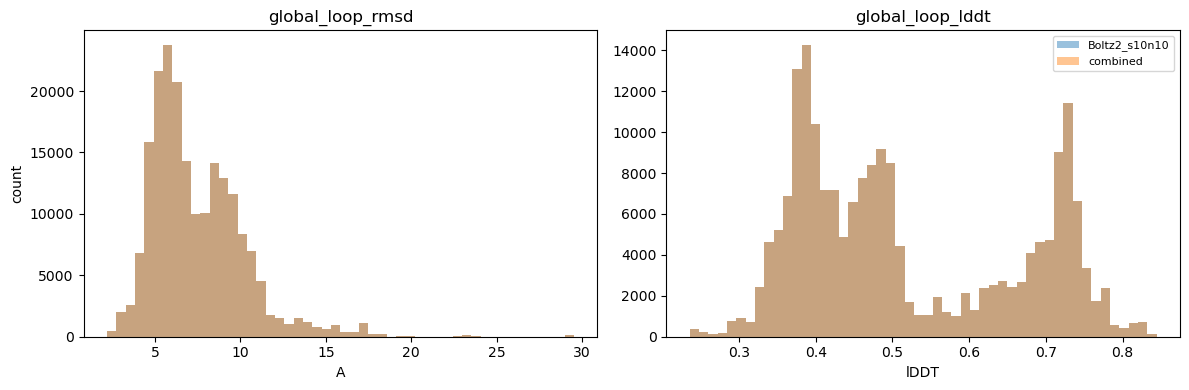

In [10]:
all_loop = []
for source in sources:
    df = tables[(source, "loop")]
    if not df.empty:
        all_loop.append(df.assign(source=source))
all_loop = pd.concat(all_loop, ignore_index=True) if all_loop else pd.DataFrame()

if not all_loop.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for source, sub in all_loop.groupby("source"):
        axes[0].hist(sub["global_loop_rmsd"].dropna(), bins=50, alpha=0.45, label=source)
        axes[1].hist(sub["global_loop_lddt"].dropna(), bins=50, alpha=0.45, label=source)
    axes[0].set_title("global_loop_rmsd")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("count")
    axes[1].set_title("global_loop_lddt")
    axes[1].set_xlabel("lDDT")
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No loop metrics loaded")

In [11]:
if not all_loop.empty:
    per_cdr_rmsd = ["H1_loop_rmsd", "H2_loop_rmsd", "H3_loop_rmsd", "L1_loop_rmsd", "L2_loop_rmsd", "L3_loop_rmsd"]
    per_cdr_lddt = ["H1_loop_lddt", "H2_loop_lddt", "H3_loop_lddt", "L1_loop_lddt", "L2_loop_lddt", "L3_loop_lddt"]
    display(all_loop.groupby("source")[per_cdr_rmsd + per_cdr_lddt].agg(["count", "median", "min", "max"]))

H1_loop_rmsd                               H2_loop_rmsd  \
                     count   median       min        max        count   
source                                                                  
Boltz2_s10n10       199000  1.50838  0.134886  37.206766       199000   
combined            199000  1.50838  0.134886  37.206766       199000   

                                             H3_loop_rmsd             \
                 median       min        max        count     median   
source                                                                 
Boltz2_s10n10  3.405932  0.117391  33.557599       199000  11.734562   
combined       3.405932  0.117391  33.557599       199000  11.734562   

                                   L1_loop_rmsd                                \
                    min        max        count    median      min        max   
source                                                                          
Boltz2_s10n10  1.713149  32.968087       168600  3.179874  0.14331  27.321424   
combined       1.713149  32.968087       168600  3.179874  0.14331  27.321424   

              L2_loop_rmsd                                L3_loop_rmsd  \
                     count    median       min        max        count   
source                                                                   
Boltz2_s10n10       168400  3.691137  0.121132  17.782438       168600   
combined            168400  3.691137  0.121132  17.782438       168600   

                                             H1_loop_lddt                     \
                 median       min        max        count    median      min   
source                                                                         
Boltz2_s10n10  3.977733  0.137831  30.994471       199000  0.651679  0.03304   
combined       3.977733  0.137831  30.994471       199000  0.651679  0.03304   

                        H2_loop_lddt                                \
                    max        count    median       min       max   
source                                                               
Boltz2_s10n10  0.893959       199000  0.512926  0.190388  0.949897   
combined       0.893959       199000  0.512926  0.190388  0.949897   

              H3_loop_lddt                               L1_loop_lddt  \
                     count    median       min       max        count   
source                                                                  
Boltz2_s10n10       199000  0.309907  0.131249  0.699645       168600   
combined            199000  0.309907  0.131249  0.699645       168600   

                                            L2_loop_lddt                      \
                 median       min       max        count    median       min   
source                                                                         
Boltz2_s10n10  0.520734  0.225423  0.991642       168400  0.425482  0.183171   
combined       0.520734  0.225423  0.991642       168400  0.425482  0.183171   

                        L3_loop_lddt                                
                    max        count    median       min       max  
source                                                              
Boltz2_s10n10  0.997428       168600  0.459499  0.120219  0.971124  
combined       0.997428       168600  0.459499  0.120219  0.971124

## Inspect One Target

In [12]:
if not loop_df.empty:
    TARGET_ID = loop_df["target_id"].iloc[0]
    sub = loop_df[loop_df["target_id"] == TARGET_ID].copy()
    print("SOURCE =", SOURCE, "TARGET_ID =", TARGET_ID, "n =", len(sub))
    display(target_df[target_df["target_id"] == TARGET_ID])
    display(sub.sort_values("global_loop_rmsd").head(20))

SOURCE = Boltz2_s10n10 TARGET_ID = 15c8_H_L n = 100


,target_id,source,native_path,target_pickle_path,has_holo_antigen,antibody_chains,antigen_chains,num_total_residues_original,H1_count,H2_count,H3_count,L1_count,L2_count,L3_count
0,15c8_H_L,Boltz2_s10n10,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/15c8_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/15c8_H_L.pkl,False,"H,L",,227,7,6,10,12,7,9


,target_id,source,seed,sample,decoy_id,native_path,decoy_path,target_pickle_path,ranking,ranking_score,global_loop_rmsd,global_loop_lddt,H1_loop_rmsd,H2_loop_rmsd,H3_loop_rmsd,L1_loop_rmsd,L2_loop_rmsd,L3_loop_rmsd,H1_loop_lddt,H2_loop_lddt,H3_loop_lddt,L1_loop_lddt,L2_loop_lddt,L3_loop_lddt,missing_backbone_atom_count,missing_backbone_report
13,15c8_H_L,Boltz2_s10n10,43,3,seed=43:sample=3,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/15c8_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/15c8_H_L/seed_43/boltz_results_15c8_H_L/predictions/15c8_H_L/15c8_H_L_model_3.cif,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/15c8_H_L.pkl,40,0.976715,5.287986,0.505716,1.552007,3.493857,10.884199,2.159941,3.613311,3.805864,0.662750,0.528133,0.334832,0.571187,0.430887,0.501203,0,
67,15c8_H_L,Boltz2_s10n10,48,7,seed=48:sample=7,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/15c8_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/15c8_H_L/seed_48/boltz_results_15c8_H_L/predictions/15c8_H_L/15c8_H_L_model_7.cif,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/15c8_H_L.pkl,63,0.976278,5.385680,0.499828,1.434648,3.449051,11.219720,2.145448,3.570993,3.813773,0.662681,0.528116,0.310078,0.570702,0.423453,0.498897,0,
57,15c8_H_L,Boltz2_s10n10,47,7,seed=47:sample=7,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/15c8_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/15c8_H_L/seed_47/boltz_results_15c8_H_L/predictions/15c8_H_L/15c8_H_L_model_7.cif,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/15c8_H_L.pkl,91,0.975587,5.388234,0.502101,1.314589,3.457301,11.232002,2.112393,3.543379,3.819812,0.661724,0.529262,0.316271,0.572532,0.425957,0.501181,0,
75,15c8_H_L,Boltz2_s10n10,49,5,seed=49:sample=5,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/15c8_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/15c8_H_L/seed_49/boltz_results_15c8_H_L/predictions/15c8_H_L/15c8_H_L_model_5.cif,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/15c8_H_L.pkl,64,0.976262,5.392096,0.501552,1.513767,3.514652,11.203389,2.165345,3.604387,3.797777,0.665144,0.529226,0.313564,0.571332,0.424447,0.500722,0,
23,15c8_H_L,Boltz2_s10n10,44,3,seed=44:sample=3,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/15c8_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/15c8_H_L/seed_44/boltz_results_15c8_H_L/predictions/15c8_H_L/15c8_H_L_model_3.cif,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/15c8_H_L.pkl,32,0.976842,5.394891,0.500180,1.382835,3.552868,11.232834,2.163198,3.558118,3.814846,0.661906,0.524766,0.314419,0.570867,0.425468,0.497569,0,
36,15c8_H_L,Boltz2_s10n10,45,6,seed=45:sample=6,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/15c8_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/15c8_H_L/seed_45/boltz_results_15c8_H_L/predictions/15c8_H_L/15c8_H_L_model_6.cif,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/15c8_H_L.pkl,22,0.976991,5.399890,0.501121,1.306377,3.521211,11.261171,2.108147,3.513129,3.822655,0.663612,0.526399,0.311443,0.572335,0.426509,0.500290,0,
9,15c8_H_L,Boltz2_s10n10,42,9,seed=42:sample=9,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/15c8_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/15c8_H_L/seed_42/boltz_results_15c8_H_L/predictions/15c8_H_L/15c8_H_L_model_9.cif,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/15c8_H_L.pkl,88,0.975760,5.407685,0.501262,1.353443,3.501329,11.286556,2.118419,3.547762,3.818057,0.663329,0.527257,0.313360,0.572143,0.424591,0.500794,0,
91,15c8_H_L,Boltz2_s10n10,51,1,seed=51:sample=1,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/15c8_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10

## Boltz2 Apo vs Holo Analysis

The following cells focus on Boltz2 and split decoys by the target-level `has_holo_antigen` flag from `targets/target_metrics.parquet`.

In [13]:
boltz_source = next((s for s in sources if s.lower().startswith("boltz2")), None)
if boltz_source is None:
    raise ValueError(f"Boltz2 source was not found under {METRICS_ROOT}; available sources={sources}")

boltz_loop = tables[(boltz_source, "loop")].copy()
boltz_targets = tables[(boltz_source, "targets")].copy()

target_state_cols = ["target_id", "source", "has_holo_antigen", "antigen_chains"]
boltz = boltz_loop.merge(
    boltz_targets[target_state_cols].drop_duplicates(),
    on=["target_id", "source"],
    how="left",
)
boltz["target_state"] = np.where(boltz["has_holo_antigen"].fillna(False), "holo", "apo")

print("Boltz2 rows:", len(boltz), "targets:", boltz["target_id"].nunique())
display(boltz.groupby("target_state").agg(rows=("target_id", "size"), targets=("target_id", "nunique")))
display(boltz.head())

Boltz2 rows: 199000 targets: 1990


,rows,targets
target_state,,
apo,71700,717
holo,127300,1273


,target_id,source,seed,sample,decoy_id,native_path,decoy_path,target_pickle_path,ranking,ranking_score,global_loop_rmsd,global_loop_lddt,H1_loop_rmsd,H2_loop_rmsd,H3_loop_rmsd,L1_loop_rmsd,L2_loop_rmsd,L3_loop_rmsd,H1_loop_lddt,H2_loop_lddt,H3_loop_lddt,L1_loop_lddt,L2_loop_lddt,L3_loop_lddt,missing_backbone_atom_count,missing_backbone_report,has_holo_antigen,antigen_chains,target_state
0,15c8_H_L,Boltz2_s10n10,42,0,seed=42:sample=0,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/15c8_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/15c8_H_L/seed_42/boltz_results_15c8_H_L/predictions/15c8_H_L/15c8_H_L_model_0.cif,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/15c8_H_L.pkl,7,0.977430,5.441364,0.500222,1.447834,3.514403,11.363980,2.127388,3.545602,3.811515,0.661307,0.525751,0.310156,0.572819,0.423842,0.500379,0,,False,,apo
1,15c8_H_L,Boltz2_s10n10,42,1,seed=42:sample=1,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/15c8_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/15c8_H_L/seed_42/boltz_results_15c8_H_L/predictions/15c8_H_L/15c8_H_L_model_1.cif,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/15c8_H_L.pkl,10,0.977244,5.488320,0.497151,1.477014,3.451420,11.468045,2.164072,3.641200,3.848921,0.663466,0.526817,0.295940,0.570122,0.419588,0.501306,0,,False,,apo
2,15c8_H_L,Boltz2_s10n10,42,2,seed=42:sample=2,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/15c8_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/15c8_H_L/seed_42/boltz_results_15c8_H_L/predictions/15c8_H_L/15c8_H_L_model_2.cif,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/15c8_H_L.pkl,17,0.977143,5.498769,0.498176,1.210876,3.344100,11.573737,2.086798,3.504096,3.871458,0.661341,0.526621,0.298509,0.572601,0.421472,0.501645,0,,False,,apo
3,15c8_H_L,Boltz2_s10n10,42,3,seed=42:sample=3,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/15c8_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/15c8_H_L/seed_42/boltz_results_15c8_H_L/predictions/15c8_H_L/15c8_H_L_model_3.cif,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/15c8_H_L.pkl,37,0.976731,5.436716,0.499577,1.415216,3.515223,11.339110,2.138310,3.555685,3.837407,0.661572,0.526899,0.307649,0.571452,0.423142,0.500606,0,,False,,apo
4,15c8_H_L,Boltz2_s10n10,42,4,seed=42:sample=4,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/00_crystal/15c8_H_L.pdb,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/14_boltz2_s10n10/15c8_H_L/seed_42/boltz_results_15c8_H_L/predictions/15c8_H_L/15c8_H_L_model_4.cif,/home/sujin/DB/h3-loop-modeling/ab_ag/1_tr_abag/15_boltz2_s10n10_pdb2dict/15c8_H_L.pkl,52,0.976484,5.430873,0.501313,1.552402,3.509310,11.292969,2.144620,3.583991,3.819227,0.665002,0.528004,0.311432,0.571487,0.423961,0.502347,0,,False,,apo


### Figure 1. Boltz2 global_loop_rmsd / global_loop_lddt distribution, apo vs holo

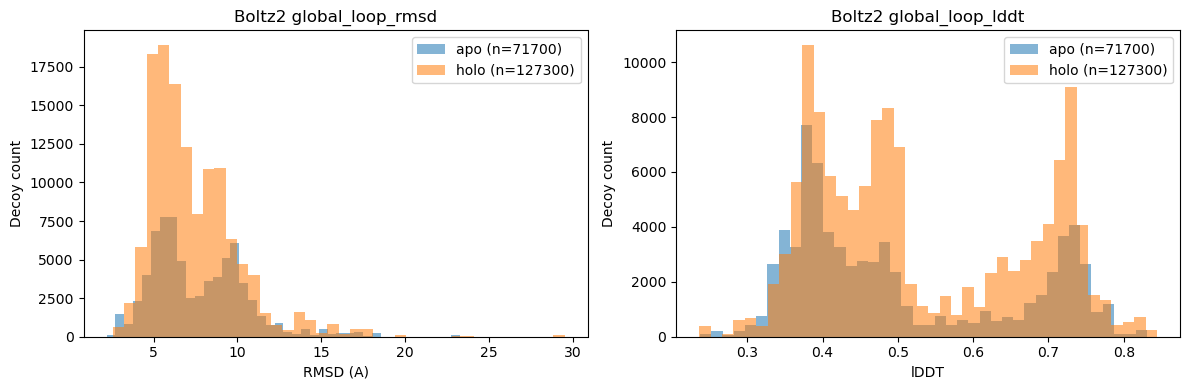

global_loop_rmsd                                           \
                        count    median      mean       min        max   
target_state                                                             
apo                     71700  6.927643  7.635756  2.190085  23.297270   
holo                   127300  6.695839  7.349455  2.562449  29.521523   

             global_loop_lddt                                          
                        count    median      mean       min       max  
target_state                                                           
apo                     71700  0.448595  0.503148  0.237468  0.831263  
holo                   127300  0.485218  0.527850  0.235809  0.844340

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = {"apo": "tab:blue", "holo": "tab:orange"}

for state, sub in boltz.groupby("target_state"):
    axes[0].hist(sub["global_loop_rmsd"].dropna(), bins=40, alpha=0.55, label=f"{state} (n={len(sub)})", color=colors.get(state))
    axes[1].hist(sub["global_loop_lddt"].dropna(), bins=40, alpha=0.55, label=f"{state} (n={len(sub)})", color=colors.get(state))

axes[0].set_title("Boltz2 global_loop_rmsd")
axes[0].set_xlabel("RMSD (A)")
axes[0].set_ylabel("Decoy count")
axes[0].legend()

axes[1].set_title("Boltz2 global_loop_lddt")
axes[1].set_xlabel("lDDT")
axes[1].set_ylabel("Decoy count")
axes[1].legend()

plt.tight_layout()
plt.show()

display(boltz.groupby("target_state")[["global_loop_rmsd", "global_loop_lddt"]].agg(["count", "median", "mean", "min", "max"]))

### Figure 2. Per-CDR loop_rmsd boxplot: H1-H3/L1-L3, apo vs holo

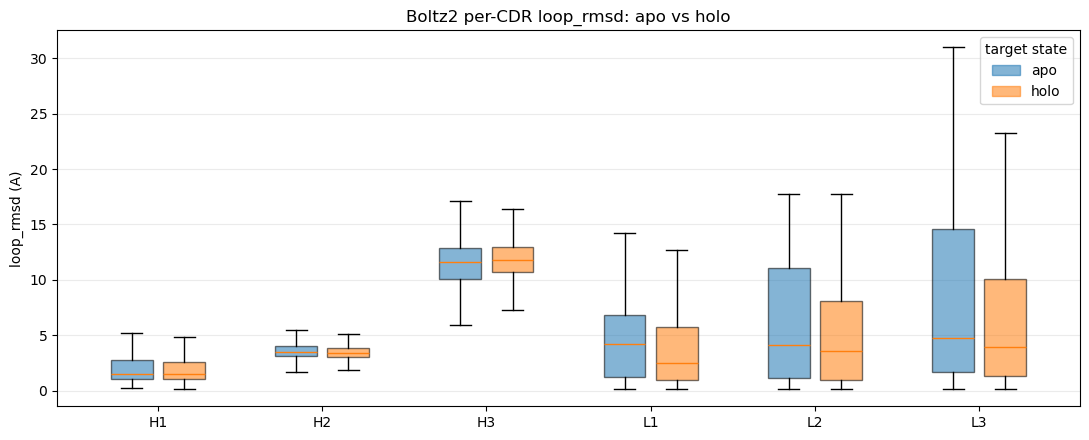

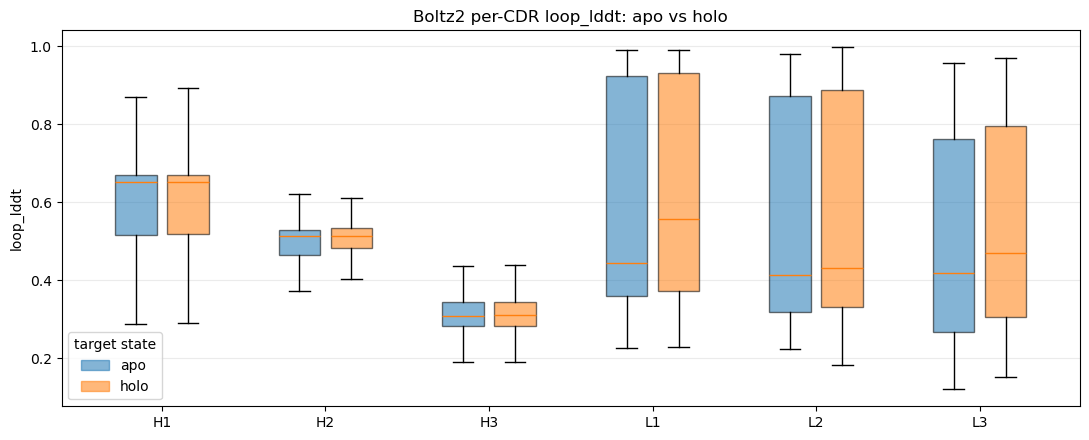

Per-CDR RMSD summary


H1_loop_rmsd                     H2_loop_rmsd            \
                    count    median      mean        count    median   
target_state                                                           
apo                 71700  1.509512  2.387636        71700  3.441207   
holo               127300  1.507671  2.220258       127300  3.387437   

                       H3_loop_rmsd                       L1_loop_rmsd  \
                  mean        count     median       mean        count   
target_state                                                             
apo           3.991518        71700  11.649332  11.648153        64300   
holo          3.790318       127300  11.817895  12.024701       104300   

                                 L2_loop_rmsd                      \
                median      mean        count    median      mean   
target_state                                                        
apo           4.161913  4.368556        64100  4.078646  5.785021   
holo          2.516197  3.754875       104300  3.568437  4.642967   

             L3_loop_rmsd                      
                    count    median      mean  
target_state                                   
apo                 64300  4.752345  7.510880  
holo               104300  3.899473  5.917513

Per-CDR lDDT summary


H1_loop_lddt                     H2_loop_lddt            \
                    count    median      mean        count    median   
target_state                                                           
apo                 71700  0.651412  0.603775        71700  0.512475   
holo               127300  0.651770  0.610351       127300  0.513171   

                       H3_loop_lddt                    L1_loop_lddt            \
                  mean        count    median     mean        count    median   
target_state                                                                    
apo           0.516939        71700  0.308595  0.31357        64300  0.444712   
holo          0.537090       127300  0.310527  0.31514       104300  0.558224   

                       L2_loop_lddt                     L3_loop_lddt  \
                  mean        count    median      mean        count   
target_state                                                           
apo           0.572050        64100  0.414486  0.534133        64300   
holo          0.621611       104300  0.431520  0.580154       104300   

                                  
                median      mean  
target_state                      
apo           0.417662  0.493094  
holo          0.470308  0.537904

In [15]:
cdr_order = ["H1", "H2", "H3", "L1", "L2", "L3"]
rmsd_cols = [f"{cdr}_loop_rmsd" for cdr in cdr_order]
lddt_cols = [f"{cdr}_loop_lddt" for cdr in cdr_order]


def _plot_per_cdr_state_boxplot(metric_cols, ylabel, title):
    box_data = []
    positions = []
    box_colors = []
    pos = 1
    for col in metric_cols:
        for offset, state in enumerate(["apo", "holo"]):
            values = pd.to_numeric(boltz.loc[boltz["target_state"] == state, col], errors="coerce").dropna().to_numpy()
            box_data.append(values if len(values) else np.array([np.nan]))
            positions.append(pos + offset * 0.35)
            box_colors.append(colors.get(state, "gray"))
        pos += 1.1

    fig, ax = plt.subplots(figsize=(11, 4.5))
    bp = ax.boxplot(box_data, positions=positions, widths=0.28, patch_artist=True, showfliers=False)
    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.55)

    centers = [1 + i * 1.1 + 0.175 for i in range(len(cdr_order))]
    ax.set_xticks(centers)
    ax.set_xticklabels(cdr_order)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)

    handles = [plt.Rectangle((0, 0), 1, 1, color=colors[state], alpha=0.55) for state in ["apo", "holo"]]
    ax.legend(handles, ["apo", "holo"], title="target state")
    plt.tight_layout()
    plt.show()


_plot_per_cdr_state_boxplot(rmsd_cols, "loop_rmsd (A)", "Boltz2 per-CDR loop_rmsd: apo vs holo")
_plot_per_cdr_state_boxplot(lddt_cols, "loop_lddt", "Boltz2 per-CDR loop_lddt: apo vs holo")

print("Per-CDR RMSD summary")
display(boltz.groupby("target_state")[rmsd_cols].agg(["count", "median", "mean"]))
print("Per-CDR lDDT summary")
display(boltz.groupby("target_state")[lddt_cols].agg(["count", "median", "mean"]))


### ComMat vs Boltz2 2D Density: global_loop_lddt vs H3_loop_lddt

This compares the decoy-level quality distribution of ComMat and Boltz2. Higher values are better for both axes.


Missing source: ComMat; available sources=['Boltz2_s10n10', 'combined']


,,rows,targets
plot_source,source,,
Boltz2,Boltz2_s10n10,199000,1990


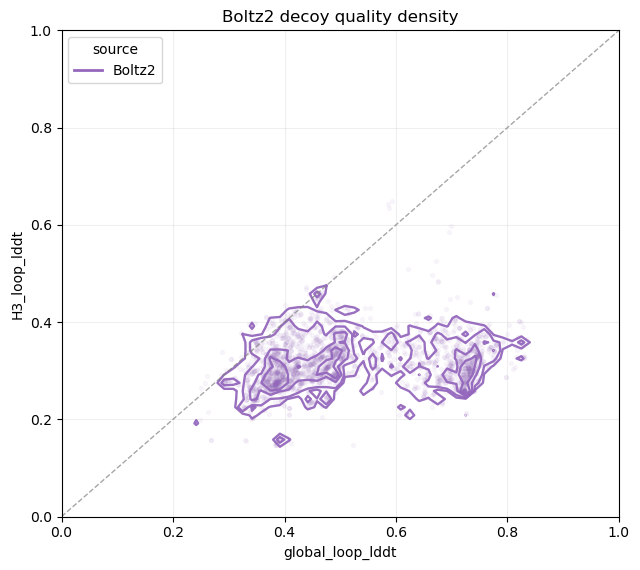

In [16]:
compare_source_specs = [
    ("ComMat", ("commat",)),
    ("Boltz2", ("boltz2",)),
]
compare_sources = []
source_display_names = {}
for display_name, aliases in compare_source_specs:
    source = next(
        (
            s
            for s in sources
            if any(s.lower() == alias or s.lower().startswith(f"{alias}_") for alias in aliases)
        ),
        None,
    )
    if source is None:
        print(f"Missing source: {display_name}; available sources={sources}")
    else:
        compare_sources.append(source)
        source_display_names[source] = display_name

required_cols = ["target_id", "global_loop_lddt", "H3_loop_lddt"]
density_frames = []
for source in compare_sources:
    df = tables[(source, "loop")]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        print(f"Skip {source}: missing {missing}")
        continue
    sub = df[required_cols].copy()
    sub["global_loop_lddt"] = pd.to_numeric(sub["global_loop_lddt"], errors="coerce")
    sub["H3_loop_lddt"] = pd.to_numeric(sub["H3_loop_lddt"], errors="coerce")
    sub = sub.dropna(subset=["global_loop_lddt", "H3_loop_lddt"])
    if sub.empty:
        print(f"Skip {source}: no finite global_loop_lddt/H3_loop_lddt rows")
        continue
    sub["source"] = source
    sub["plot_source"] = source_display_names[source]
    density_frames.append(sub)

if not density_frames:
    raise ValueError(f"No ComMat/Boltz2 loop lDDT data available for density plot; available sources={sources}")

density_df = pd.concat(density_frames, ignore_index=True)
display(density_df.groupby(["plot_source", "source"]).agg(rows=("target_id", "size"), targets=("target_id", "nunique")))

source_colors = {"ComMat": "tab:green", "Boltz2": "tab:purple"}
fig, ax = plt.subplots(figsize=(6.5, 5.8))

for source in compare_sources:
    display_name = source_display_names[source]
    sub = density_df[density_df["plot_source"] == display_name]
    if sub.empty:
        continue
    x = sub["global_loop_lddt"].to_numpy(dtype=float)
    y = sub["H3_loop_lddt"].to_numpy(dtype=float)
    sample = sub.sample(min(len(sub), 2500), random_state=0)
    color = source_colors.get(display_name, None)
    ax.scatter(
        sample["global_loop_lddt"],
        sample["H3_loop_lddt"],
        s=8,
        alpha=0.05,
        color=color,
        rasterized=True,
    )

    hist, x_edges, y_edges = np.histogram2d(x, y, bins=60, range=[[0, 1], [0, 1]])
    positive = hist[hist > 0]
    if positive.size:
        levels = np.unique(np.quantile(positive, [0.55, 0.75, 0.90, 0.97]))
        levels = levels[levels > 0]
        if levels.size:
            x_centers = (x_edges[:-1] + x_edges[1:]) / 2
            y_centers = (y_edges[:-1] + y_edges[1:]) / 2
            ax.contour(
                x_centers,
                y_centers,
                hist.T,
                levels=levels,
                colors=[color],
                linewidths=1.7,
                alpha=0.95,
            )

legend_handles = [
    plt.Line2D([0], [0], color=source_colors.get(source_display_names[source], "black"), lw=2, label=source_display_names[source])
    for source in compare_sources
]
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("global_loop_lddt")
ax.set_ylabel("H3_loop_lddt")
ax.set_title(" vs ".join(source_display_names[source] for source in compare_sources) + " decoy quality density")
ax.grid(alpha=0.2)
ax.legend(handles=legend_handles, title="source")
plt.tight_layout()
plt.show()


### Boltz2 Top-1 Selection Quality

This target-level analysis evaluates whether the Boltz2 rank-1 decoy is actually good according to true Full-CDR `global_loop_lddt` within each target. `global_loop_lddt` is a loop-level lDDT metric; higher is better.

For each target:
1. Select Boltz2 rank-1 decoy using `ranking` or `boltz2_rank`.
2. Rank all Boltz2 decoys for that target by `global_loop_lddt`, higher is better.
3. Compute true rank, true percentile, oracle best lDDT, top1 lDDT, and oracle gap.

Saved outputs:
- `figures/boltz2_top1_hit_rate.png`
- `figures/boltz2_top1_percentile_bins.png`
- `figures/boltz2_top1_oracle_gap.png`
- `tables/boltz2_top1_target_level.csv`
- `tables/boltz2_top1_summary.csv`


In [17]:
ANALYSIS_OUT_DIR = METRICS_ROOT / "analysis_outputs"
FIGURES_DIR = ANALYSIS_OUT_DIR / "figures"
TABLES_DIR = ANALYSIS_OUT_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
print("Analysis outputs:", ANALYSIS_OUT_DIR)


Analysis outputs: /home/sujin/projects/cdr-scoring/cdr-data/metrics_precomputed_boltz2_s10n10_combined/analysis_outputs


In [18]:
def compute_boltz2_top1_target_level(decoy_df: pd.DataFrame) -> pd.DataFrame:
    required = {"target_id", "source", "global_loop_lddt"}
    missing = required - set(decoy_df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    rank_col = "boltz2_rank" if "boltz2_rank" in decoy_df.columns else "ranking"
    if rank_col not in decoy_df.columns:
        raise ValueError("Expected either ranking or boltz2_rank column")

    work = decoy_df.copy()
    work[rank_col] = pd.to_numeric(work[rank_col], errors="coerce")
    work["global_loop_lddt"] = pd.to_numeric(work["global_loop_lddt"], errors="coerce")
    if "ranking_score" in work.columns:
        work["ranking_score"] = pd.to_numeric(work["ranking_score"], errors="coerce")
    else:
        work["ranking_score"] = np.nan
    if "target_state" not in work.columns:
        if "has_holo_antigen" in work.columns:
            work["target_state"] = np.where(work["has_holo_antigen"].fillna(False), "holo", "apo")
        else:
            work["target_state"] = "unknown"

    rows = []
    for target_id, sub in work.groupby("target_id", dropna=False):
        finite = sub.dropna(subset=["global_loop_lddt"]).copy()
        ranked = finite.dropna(subset=[rank_col]).copy()
        if finite.empty or ranked.empty:
            continue

        ranked = ranked.sort_values([rank_col, "ranking_score", "sample"], ascending=[True, False, True], kind="mergesort")
        top1 = ranked.iloc[0]
        n_decoys = int(len(finite))
        top1_lddt = float(top1["global_loop_lddt"])
        oracle_best_lddt = float(finite["global_loop_lddt"].max())
        top1_true_rank = int((finite["global_loop_lddt"] > top1_lddt).sum()) + 1
        top1_true_percentile = (n_decoys - top1_true_rank + 1) / n_decoys
        oracle_gap = oracle_best_lddt - top1_lddt

        rows.append({
            "target_id": target_id,
            "source": top1.get("source", "Boltz2"),
            "target_state": top1.get("target_state", "unknown"),
            "has_holo_antigen": bool(top1.get("has_holo_antigen", False)),
            "n_decoys": n_decoys,
            "boltz2_rank_col": rank_col,
            "boltz2_top1_rank": top1.get(rank_col, np.nan),
            "boltz2_top1_sample": top1.get("sample", np.nan),
            "boltz2_top1_ranking_score": top1.get("ranking_score", np.nan),
            "top1_true_rank": top1_true_rank,
            "top1_true_percentile": float(top1_true_percentile),
            "oracle_best_lddt": oracle_best_lddt,
            "boltz2_top1_lddt": top1_lddt,
            "oracle_gap": float(oracle_gap),
        })
    return pd.DataFrame(rows)

boltz_top1_target = compute_boltz2_top1_target_level(boltz)
target_level_path = TABLES_DIR / "boltz2_top1_target_level.csv"
boltz_top1_target.to_csv(target_level_path, index=False)
print("target-level rows:", len(boltz_top1_target), "saved:", target_level_path)
display(boltz_top1_target.head(20))


target-level rows: 1990 saved: /home/sujin/projects/cdr-scoring/cdr-data/metrics_precomputed_boltz2_s10n10_combined/analysis_outputs/tables/boltz2_top1_target_level.csv


,target_id,source,target_state,has_holo_antigen,n_decoys,boltz2_rank_col,boltz2_top1_rank,boltz2_top1_sample,boltz2_top1_ranking_score,top1_true_rank,top1_true_percentile,oracle_best_lddt,boltz2_top1_lddt,oracle_gap
0,15c8_H_L,Boltz2_s10n10,apo,False,100,ranking,1,0,0.977836,13,0.88,0.505716,0.500639,0.005077
1,1a0q_H_L,Boltz2_s10n10,apo,False,100,ranking,1,0,0.962260,22,0.79,0.460003,0.455699,0.004305
2,1a14_H_L_A,Boltz2_s10n10,holo,True,100,ranking,1,0,0.934582,5,0.96,0.737091,0.736585,0.000506
3,1a3l_H_L,Boltz2_s10n10,apo,False,100,ranking,1,0,0.957215,34,0.67,0.379997,0.375785,0.004212
4,1a4j_H_L,Boltz2_s10n10,apo,False,100,ranking,1,0,0.972004,47,0.54,0.376591,0.371974,0.004617
5,1a5f_H_L,Boltz2_s10n10,apo,False,100,ranking,1,0,0.965370,86,0.15,0.380652,0.376503,0.004149
6,1a6t_H_L,Boltz2_s10n10,apo,False,100,ranking,1,0,0.962162,44,0.57,0.490460,0.488129,0.002332
7,1acy_H_L_A,Boltz2_s10n10,holo,True,100,ranking,1,0,0.984256,43,0.58,0.342285,0.340242,0.002043
8,1ad0_H_L,Boltz2_s10n10,apo,False,100,ranking,1,0,0.958204,81,0.20,0.444874,0.441436,0.003438
9,1ad9_H_L,Boltz2_s10n10,apo,False,100,ranking,1,0,0.951279,96,0.05,0.385615,0.377044,0.008571


In [19]:
def _summary_for_group(df: pd.DataFrame, group: str) -> dict:
    if df.empty:
        return {
            "group": group,
            "n_targets": 0,
            "fraction_true_best": np.nan,
            "fraction_true_top5_percent": np.nan,
            "fraction_true_top10_percent": np.nan,
            "fraction_true_top25_percent": np.nan,
            "fraction_true_top50_percent": np.nan,
            "median_true_percentile": np.nan,
            "mean_true_percentile": np.nan,
            "median_oracle_gap": np.nan,
            "mean_oracle_gap": np.nan,
            "fraction_gap_lt_0.01": np.nan,
            "fraction_gap_lt_0.05": np.nan,
        }
    percentile = df["top1_true_percentile"]
    gap = df["oracle_gap"]
    return {
        "group": group,
        "n_targets": int(len(df)),
        "fraction_true_best": float((df["top1_true_rank"] == 1).mean()),
        "fraction_true_top5_percent": float((percentile >= 0.95).mean()),
        "fraction_true_top10_percent": float((percentile >= 0.90).mean()),
        "fraction_true_top25_percent": float((percentile >= 0.75).mean()),
        "fraction_true_top50_percent": float((percentile >= 0.50).mean()),
        "median_true_percentile": float(percentile.median()),
        "mean_true_percentile": float(percentile.mean()),
        "median_oracle_gap": float(gap.median()),
        "mean_oracle_gap": float(gap.mean()),
        "fraction_gap_lt_0.01": float((gap < 0.01).mean()),
        "fraction_gap_lt_0.05": float((gap < 0.05).mean()),
    }

summary_rows = [_summary_for_group(boltz_top1_target, "all")]
for state in ["apo", "holo"]:
    summary_rows.append(_summary_for_group(boltz_top1_target[boltz_top1_target["target_state"] == state], state))

boltz_top1_summary = pd.DataFrame(summary_rows)
summary_path = TABLES_DIR / "boltz2_top1_summary.csv"
boltz_top1_summary.to_csv(summary_path, index=False)
print("saved:", summary_path)
display(boltz_top1_summary)


saved: /home/sujin/projects/cdr-scoring/cdr-data/metrics_precomputed_boltz2_s10n10_combined/analysis_outputs/tables/boltz2_top1_summary.csv


,group,n_targets,fraction_true_best,fraction_true_top5_percent,fraction_true_top10_percent,fraction_true_top25_percent,fraction_true_top50_percent,median_true_percentile,mean_true_percentile,median_oracle_gap,mean_oracle_gap,fraction_gap_lt_0.01,fraction_gap_lt_0.05
0,all,1990,0.010050,0.058291,0.109045,0.253266,0.499497,0.49,0.492814,0.002430,0.004586,0.904020,0.994472
1,apo,717,0.012552,0.064156,0.118550,0.263598,0.509066,0.51,0.504017,0.002970,0.005259,0.894003,0.993026
2,holo,1273,0.008641,0.054988,0.103692,0.247447,0.494108,0.49,0.486504,0.002124,0.004207,0.909662,0.995287


### Figure A. Top-k Hit Rate Bar Plot

Fraction of targets where Boltz2 rank-1 falls within the true-quality group defined by Full-CDR `global_loop_lddt`.


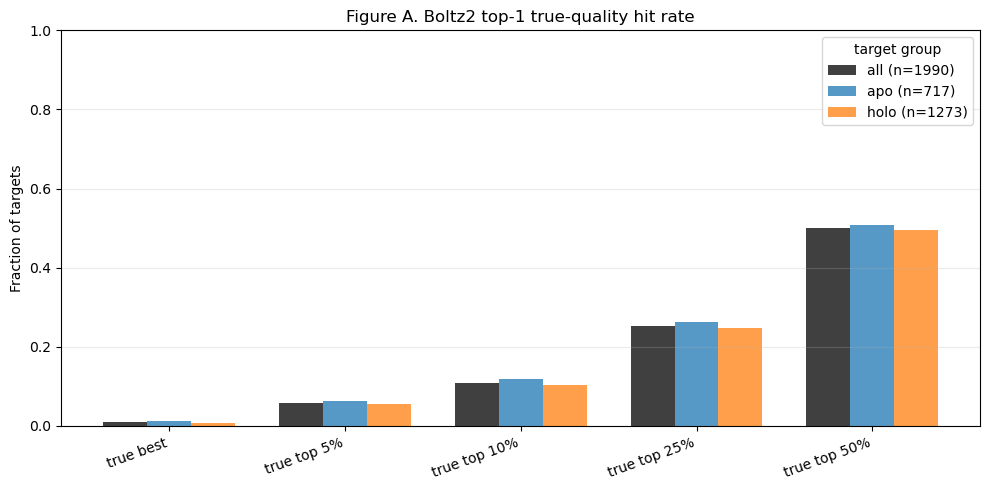

saved: /home/sujin/projects/cdr-scoring/cdr-data/metrics_precomputed_boltz2_s10n10_combined/analysis_outputs/figures/boltz2_top1_hit_rate.png


In [20]:
hit_cols = [
    "fraction_true_best",
    "fraction_true_top5_percent",
    "fraction_true_top10_percent",
    "fraction_true_top25_percent",
    "fraction_true_top50_percent",
]
hit_labels = ["true best", "true top 5%", "true top 10%", "true top 25%", "true top 50%"]
groups = ["all", "apo", "holo"]
group_colors = {"all": "black", "apo": colors.get("apo", "tab:blue"), "holo": colors.get("holo", "tab:orange")}

x = np.arange(len(hit_cols))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
for i, group in enumerate(groups):
    row = boltz_top1_summary[boltz_top1_summary["group"] == group].iloc[0]
    values = [row[col] for col in hit_cols]
    ax.bar(x + (i - 1) * width, values, width=width, label=f"{group} (n={int(row['n_targets'])})", color=group_colors[group], alpha=0.75)

ax.set_xticks(x)
ax.set_xticklabels(hit_labels, rotation=20, ha="right")
ax.set_ylim(0, 1.0)
ax.set_ylabel("Fraction of targets")
ax.set_title("Figure A. Boltz2 top-1 true-quality hit rate")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="target group")
plt.tight_layout()
fig_path = FIGURES_DIR / "boltz2_top1_hit_rate.png"
plt.savefig(fig_path, dpi=200)
plt.show()
print("saved:", fig_path)


### Figure A2. Top-1 Hit Rate by Loop Metric

This repeats the same top-1 selection-quality analysis for global and per-CDR loop lDDT/RMSD. lDDT uses higher-is-better ranking; RMSD uses lower-is-better ranking.


saved: /home/sujin/projects/cdr-scoring/cdr-data/metrics_precomputed_boltz2_s10n10_combined/analysis_outputs/tables/boltz2_top1_by_metric_target_level.csv
saved: /home/sujin/projects/cdr-scoring/cdr-data/metrics_precomputed_boltz2_s10n10_combined/analysis_outputs/tables/boltz2_top1_by_metric_summary.csv


,metric_label,group,n_targets,fraction_true_best,fraction_true_top10_percent,fraction_true_top25_percent,median_true_percentile,median_oracle_gap
0,global lDDT,all,1990,0.010050,0.109045,0.253266,0.490,0.002430
1,global lDDT,apo,717,0.012552,0.118550,0.263598,0.510,0.002970
2,global lDDT,holo,1273,0.008641,0.103692,0.247447,0.490,0.002124
3,H1 lDDT,all,1990,0.012563,0.128141,0.269347,0.510,0.003862
4,H1 lDDT,apo,717,0.013947,0.122734,0.270572,0.520,0.004496
5,H1 lDDT,holo,1273,0.011783,0.131186,0.268657,0.510,0.003471
6,H2 lDDT,all,1990,0.009548,0.129146,0.270352,0.490,0.003920
7,H2 lDDT,apo,717,0.009763,0.131102,0.264993,0.490,0.004333
8,H2 lDDT,holo,1273,0.009427,0.128044,0.273370,0.490,0.003667
9,H3 lDDT,all,1990,0.011558,0.099497,0.234171,0.480,0.004201


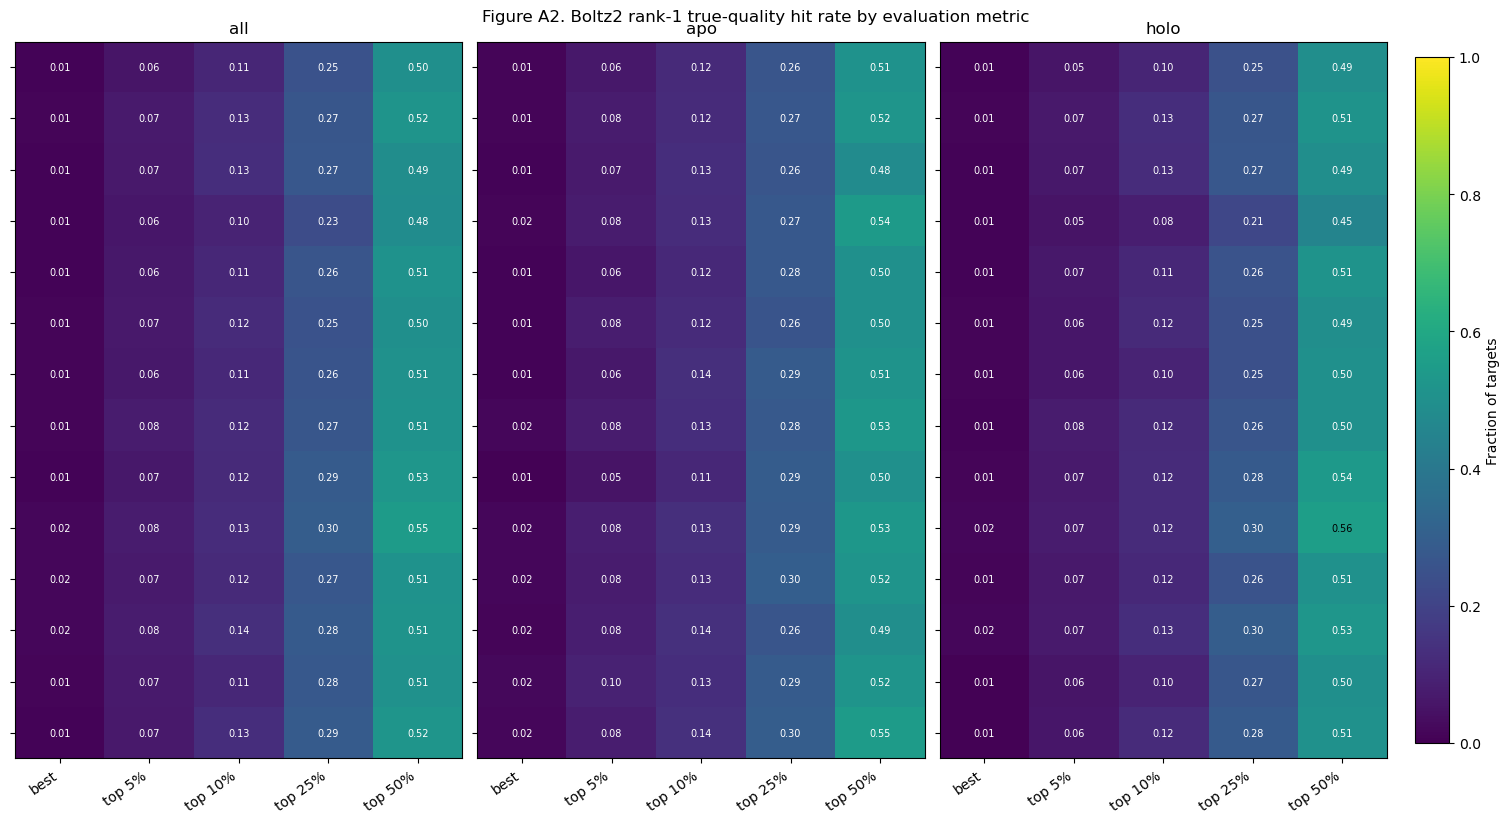

saved: /home/sujin/projects/cdr-scoring/cdr-data/metrics_precomputed_boltz2_s10n10_combined/analysis_outputs/figures/boltz2_top1_metric_hit_rate.png


In [21]:
def compute_boltz2_top1_target_level_for_metric(decoy_df: pd.DataFrame, metric_col: str, higher_is_better: bool) -> pd.DataFrame:
    required = {"target_id", "source", metric_col}
    missing = required - set(decoy_df.columns)
    if missing:
        raise ValueError(f"Missing required columns for {metric_col}: {sorted(missing)}")

    rank_col = "boltz2_rank" if "boltz2_rank" in decoy_df.columns else "ranking"
    if rank_col not in decoy_df.columns:
        raise ValueError("Expected either ranking or boltz2_rank column")

    work = decoy_df.copy()
    work[rank_col] = pd.to_numeric(work[rank_col], errors="coerce")
    work[metric_col] = pd.to_numeric(work[metric_col], errors="coerce")
    if "ranking_score" in work.columns:
        work["ranking_score"] = pd.to_numeric(work["ranking_score"], errors="coerce")
    else:
        work["ranking_score"] = np.nan
    if "target_state" not in work.columns:
        if "has_holo_antigen" in work.columns:
            work["target_state"] = np.where(work["has_holo_antigen"].fillna(False), "holo", "apo")
        else:
            work["target_state"] = "unknown"

    sort_cols = [rank_col]
    ascending = [True]
    if "ranking_score" in work.columns:
        sort_cols.append("ranking_score")
        ascending.append(False)
    if "sample" in work.columns:
        sort_cols.append("sample")
        ascending.append(True)

    rows = []
    for target_id, sub in work.groupby("target_id", dropna=False):
        finite = sub.dropna(subset=[metric_col]).copy()
        ranked = finite.dropna(subset=[rank_col]).copy()
        if finite.empty or ranked.empty:
            continue

        ranked = ranked.sort_values(sort_cols, ascending=ascending, kind="mergesort")
        top1 = ranked.iloc[0]
        values = finite[metric_col]
        n_decoys = int(len(finite))
        top1_value = float(top1[metric_col])
        if higher_is_better:
            oracle_best_value = float(values.max())
            top1_true_rank = int((values > top1_value).sum()) + 1
            oracle_gap = oracle_best_value - top1_value
        else:
            oracle_best_value = float(values.min())
            top1_true_rank = int((values < top1_value).sum()) + 1
            oracle_gap = top1_value - oracle_best_value
        top1_true_percentile = (n_decoys - top1_true_rank + 1) / n_decoys

        rows.append({
            "target_id": target_id,
            "source": top1.get("source", "Boltz2"),
            "target_state": top1.get("target_state", "unknown"),
            "metric": metric_col,
            "higher_is_better": bool(higher_is_better),
            "n_decoys": n_decoys,
            "boltz2_top1_sample": top1.get("sample", np.nan),
            "boltz2_top1_ranking_score": top1.get("ranking_score", np.nan),
            "top1_true_rank": top1_true_rank,
            "top1_true_percentile": float(top1_true_percentile),
            "oracle_best_value": oracle_best_value,
            "boltz2_top1_value": top1_value,
            "oracle_gap": float(oracle_gap),
        })
    return pd.DataFrame(rows)

metric_specs = []
for prefix, label_prefix, higher in [
    ("loop_lddt", "lDDT", True),
    ("loop_rmsd", "RMSD", False),
]:
    metric_specs.append({
        "metric": f"global_{prefix}",
        "label": f"global {label_prefix}",
        "higher_is_better": higher,
    })
    for cdr in cdr_order:
        metric_specs.append({
            "metric": f"{cdr}_{prefix}",
            "label": f"{cdr} {label_prefix}",
            "higher_is_better": higher,
        })

metric_target_tables = []
metric_summary_rows = []
for spec in metric_specs:
    if spec["metric"] not in boltz.columns:
        print(f"Skip missing metric: {spec['metric']}")
        continue
    metric_target = compute_boltz2_top1_target_level_for_metric(
        boltz,
        metric_col=spec["metric"],
        higher_is_better=spec["higher_is_better"],
    )
    metric_target["metric_label"] = spec["label"]
    metric_target_tables.append(metric_target)

    for group in groups:
        sub = metric_target if group == "all" else metric_target[metric_target["target_state"] == group]
        row = _summary_for_group(sub, group)
        row.update({
            "metric": spec["metric"],
            "metric_label": spec["label"],
            "higher_is_better": spec["higher_is_better"],
        })
        metric_summary_rows.append(row)

boltz_metric_top1_target = pd.concat(metric_target_tables, ignore_index=True) if metric_target_tables else pd.DataFrame()
boltz_metric_top1_summary = pd.DataFrame(metric_summary_rows)
metric_target_path = TABLES_DIR / "boltz2_top1_by_metric_target_level.csv"
metric_summary_path = TABLES_DIR / "boltz2_top1_by_metric_summary.csv"
boltz_metric_top1_target.to_csv(metric_target_path, index=False)
boltz_metric_top1_summary.to_csv(metric_summary_path, index=False)
print("saved:", metric_target_path)
print("saved:", metric_summary_path)

display(boltz_metric_top1_summary[
    ["metric_label", "group", "n_targets", "fraction_true_best", "fraction_true_top10_percent", "fraction_true_top25_percent", "median_true_percentile", "median_oracle_gap"]
].head(30))

plot_cols = [
    "fraction_true_best",
    "fraction_true_top5_percent",
    "fraction_true_top10_percent",
    "fraction_true_top25_percent",
    "fraction_true_top50_percent",
]
plot_labels = ["best", "top 5%", "top 10%", "top 25%", "top 50%"]
metric_order = [spec["label"] for spec in metric_specs if spec["metric"] in boltz.columns]

fig, axes = plt.subplots(1, 3, figsize=(15, 8), sharey=True, constrained_layout=True)
for ax, group in zip(axes, groups):
    sub = boltz_metric_top1_summary[boltz_metric_top1_summary["group"] == group].set_index("metric_label")
    matrix = sub.reindex(metric_order)[plot_cols].to_numpy(dtype=float)
    im = ax.imshow(matrix, vmin=0, vmax=1, cmap="viridis", aspect="auto")
    ax.set_title(group)
    ax.set_xticks(np.arange(len(plot_cols)))
    ax.set_xticklabels(plot_labels, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(metric_order)))
    ax.set_yticklabels(metric_order if ax is axes[0] else [])
    for y in range(matrix.shape[0]):
        for x_idx in range(matrix.shape[1]):
            value = matrix[y, x_idx]
            if np.isfinite(value):
                ax.text(x_idx, y, f"{value:.2f}", ha="center", va="center", fontsize=7, color="white" if value < 0.55 else "black")

fig.suptitle("Figure A2. Boltz2 rank-1 true-quality hit rate by evaluation metric", y=1.01)
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label="Fraction of targets")
fig_path = FIGURES_DIR / "boltz2_top1_metric_hit_rate.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("saved:", fig_path)


### Figure B. Three-bin Percentile Summary Bar Plot

Bins: poor `0-50%`, okay `50-90%`, good `90-100%`.

,group,n_targets,poor,okay,good
0,all,1990,0.500503,0.390452,0.109045
1,apo,717,0.490934,0.390516,0.118550
2,holo,1273,0.505892,0.390416,0.103692


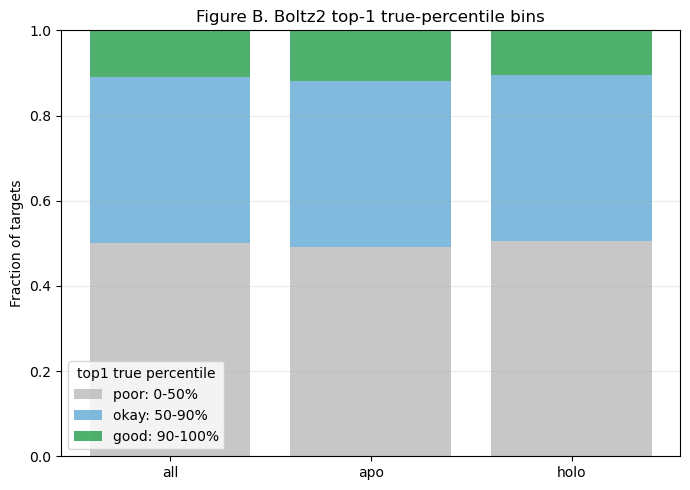

saved: /home/sujin/projects/cdr-scoring/cdr-data/metrics_precomputed_boltz2_s10n10_combined/analysis_outputs/figures/boltz2_top1_percentile_bins.png


In [22]:
def _percentile_bins(df: pd.DataFrame) -> dict:
    p = df["top1_true_percentile"]
    n = len(p)
    if n == 0:
        return {"poor": np.nan, "okay": np.nan, "good": np.nan}
    return {
        "poor": float((p < 0.50).mean()),
        "okay": float(((p >= 0.50) & (p < 0.90)).mean()),
        "good": float((p >= 0.90).mean()),
    }

bin_rows = []
for group in groups:
    sub = boltz_top1_target if group == "all" else boltz_top1_target[boltz_top1_target["target_state"] == group]
    row = {"group": group, "n_targets": len(sub)}
    row.update(_percentile_bins(sub))
    bin_rows.append(row)
bin_df = pd.DataFrame(bin_rows)
display(bin_df)

fig, ax = plt.subplots(figsize=(7, 5))
bottom = np.zeros(len(bin_df))
bin_colors = {"poor": "#bdbdbd", "okay": "#6baed6", "good": "#31a354"}
bin_labels = {
    "poor": "poor: 0-50%",
    "okay": "okay: 50-90%",
    "good": "good: 90-100%",
}
for bin_name in ["poor", "okay", "good"]:
    values = bin_df[bin_name].to_numpy(dtype=float)
    ax.bar(bin_df["group"], values, bottom=bottom, label=bin_labels[bin_name], color=bin_colors[bin_name], alpha=0.85)
    bottom += np.nan_to_num(values)

ax.set_ylim(0, 1.0)
ax.set_ylabel("Fraction of targets")
ax.set_title("Figure B. Boltz2 top-1 true-percentile bins")
ax.legend(title="top1 true percentile")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
fig_path = FIGURES_DIR / "boltz2_top1_percentile_bins.png"
plt.savefig(fig_path, dpi=200)
plt.show()
print("saved:", fig_path)


### Figure C. Oracle Gap Plot

`oracle_gap = oracle_best_lddt - boltz2_top1_lddt`. Lower is better; zero means Boltz2 rank-1 is oracle-best by Full-CDR global loop lDDT.

/tmp/ipykernel_24385/1754985012.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(gap_data, labels=gap_states, patch_artist=True, showfliers=False)


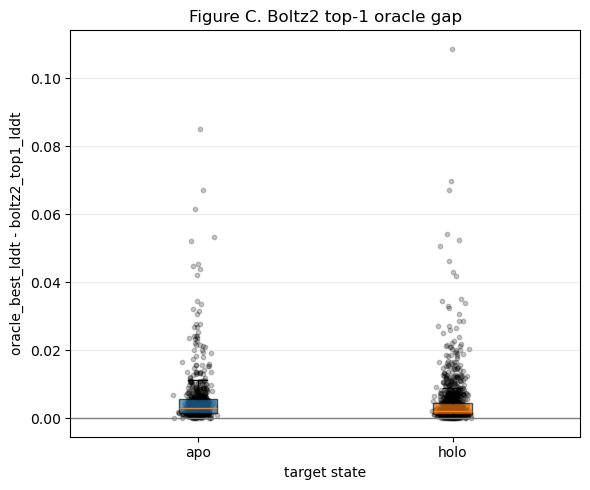

saved: /home/sujin/projects/cdr-scoring/cdr-data/metrics_precomputed_boltz2_s10n10_combined/analysis_outputs/figures/boltz2_top1_oracle_gap.png


,group,n_targets,median_oracle_gap,mean_oracle_gap,fraction_gap_lt_0.01,fraction_gap_lt_0.05
0,all,1990,0.002430,0.004586,0.904020,0.994472
1,apo,717,0.002970,0.005259,0.894003,0.993026
2,holo,1273,0.002124,0.004207,0.909662,0.995287


In [23]:
gap_states = ["apo", "holo"]
gap_data = [
    boltz_top1_target.loc[boltz_top1_target["target_state"] == state, "oracle_gap"].dropna().to_numpy()
    for state in gap_states
]

fig, ax = plt.subplots(figsize=(6, 5))
bp = ax.boxplot(gap_data, labels=gap_states, patch_artist=True, showfliers=False)
for patch, state in zip(bp["boxes"], gap_states):
    patch.set_facecolor(colors.get(state, "gray"))
    patch.set_alpha(0.65)

rng = np.random.default_rng(0)
for x_pos, values in enumerate(gap_data, start=1):
    if len(values) == 0:
        continue
    jitter = rng.normal(loc=0.0, scale=0.025, size=len(values))
    ax.scatter(np.full(len(values), x_pos) + jitter, values, s=10, alpha=0.22, color="black")

ax.axhline(0, color="gray", linewidth=1)
ax.set_xlabel("target state")
ax.set_ylabel("oracle_best_lddt - boltz2_top1_lddt")
ax.set_title("Figure C. Boltz2 top-1 oracle gap")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
fig_path = FIGURES_DIR / "boltz2_top1_oracle_gap.png"
plt.savefig(fig_path, dpi=200)
plt.show()
print("saved:", fig_path)

gap_summary_cols = ["group", "n_targets", "median_oracle_gap", "mean_oracle_gap", "fraction_gap_lt_0.01", "fraction_gap_lt_0.05"]
display(boltz_top1_summary[gap_summary_cols])


In [24]:
rank_candidates = ["boltz2_rank", "ranking", "ranking_score", "sample", "seed"]
available_rank_cols = [c for c in rank_candidates if c in boltz.columns]

print("available rank cols:", available_rank_cols)
display(boltz[available_rank_cols].dtypes)
display(boltz[available_rank_cols].isna().sum())
display(boltz[["target_id", "source"] + available_rank_cols].head(20))

available rank cols: ['ranking', 'ranking_score', 'sample', 'seed']


ranking            int64
ranking_score    float64
sample             int64
seed               int64
dtype: object

ranking          0
ranking_score    0
sample           0
seed             0
dtype: int64

,target_id,source,ranking,ranking_score,sample,seed
0,15c8_H_L,Boltz2_s10n10,7,0.977430,0,42
1,15c8_H_L,Boltz2_s10n10,10,0.977244,1,42
2,15c8_H_L,Boltz2_s10n10,17,0.977143,2,42
3,15c8_H_L,Boltz2_s10n10,37,0.976731,3,42
4,15c8_H_L,Boltz2_s10n10,52,0.976484,4,42
5,15c8_H_L,Boltz2_s10n10,55,0.976405,5,42
6,15c8_H_L,Boltz2_s10n10,78,0.975939,6,42
7,15c8_H_L,Boltz2_s10n10,80,0.975837,7,42
8,15c8_H_L,Boltz2_s10n10,86,0.975776,8,42
9,15c8_H_L,Boltz2_s10n10,88,0.975760,9,42


In [25]:
rank_col = "boltz2_rank" if "boltz2_rank" in boltz.columns else "ranking"
print("rank_col used for Boltz2 top1:", rank_col)

display(
    boltz_top1_target[
        ["target_id", "source", "boltz2_rank_col", "boltz2_top1_rank",
         "boltz2_top1_sample", "boltz2_top1_ranking_score",
         "boltz2_top1_lddt", "top1_true_rank", "oracle_gap"]
    ].head(20)
)

rank_col used for Boltz2 top1: ranking


,target_id,source,boltz2_rank_col,boltz2_top1_rank,boltz2_top1_sample,boltz2_top1_ranking_score,boltz2_top1_lddt,top1_true_rank,oracle_gap
0,15c8_H_L,Boltz2_s10n10,ranking,1,0,0.977836,0.500639,13,0.005077
1,1a0q_H_L,Boltz2_s10n10,ranking,1,0,0.962260,0.455699,22,0.004305
2,1a14_H_L_A,Boltz2_s10n10,ranking,1,0,0.934582,0.736585,5,0.000506
3,1a3l_H_L,Boltz2_s10n10,ranking,1,0,0.957215,0.375785,34,0.004212
4,1a4j_H_L,Boltz2_s10n10,ranking,1,0,0.972004,0.371974,47,0.004617
5,1a5f_H_L,Boltz2_s10n10,ranking,1,0,0.965370,0.376503,86,0.004149
6,1a6t_H_L,Boltz2_s10n10,ranking,1,0,0.962162,0.488129,44,0.002332
7,1acy_H_L_A,Boltz2_s10n10,ranking,1,0,0.984256,0.340242,43,0.002043
8,1ad0_H_L,Boltz2_s10n10,ranking,1,0,0.958204,0.441436,81,0.003438
9,1ad9_H_L,Boltz2_s10n10,ranking,1,0,0.951279,0.377044,96,0.008571


### Figure 1b. Boltz2 DockQ distribution: all decoys vs best decoy

Overlay of the DockQ distribution over **all decoys** and the **per-target best decoy** (highest DockQ, oracle best). Histograms are density-normalized so the two populations (~decoys vs ~targets) are comparable. DockQ requires an antigen, so apo targets (`NaN`) are dropped. Dashed lines mark the CAPRI quality thresholds (incorrect < 0.23 ≤ acceptable < 0.49 ≤ medium < 0.80 ≤ high).

In [ ]:
boltz_dockq = tables[(boltz_source, "dockq")].copy()
boltz_dockq = boltz_dockq.merge(
    boltz_targets[target_state_cols].drop_duplicates(),
    on=["target_id", "source"],
    how="left",
)
boltz_dockq["target_state"] = np.where(boltz_dockq["has_holo_antigen"].fillna(False), "holo", "apo")

best_dockq = (
    boltz_dockq.dropna(subset=["dockq"])
    .sort_values("dockq", ascending=False)
    .groupby("target_id", as_index=False)
    .first()
)

all_vals = boltz_dockq["dockq"].dropna()
best_vals = best_dockq["dockq"].dropna()
bins = np.linspace(0, 1, 41)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(all_vals, bins=bins, density=True, alpha=0.5, color="tab:blue", label=f"all decoys (n={len(all_vals)})")
ax.hist(best_vals, bins=bins, density=True, alpha=0.5, color="tab:orange", label=f"best decoy / target (n={len(best_vals)})")

for thr, name in [(0.23, "acceptable"), (0.49, "medium"), (0.80, "high")]:
    ax.axvline(thr, color="gray", linestyle="--", linewidth=1)
    ax.text(thr, ax.get_ylim()[1] * 0.98, name, rotation=90, va="top", ha="right", fontsize=8, color="gray")

ax.set_title("Boltz2 DockQ: all decoys vs best decoy per target")
ax.set_xlabel("DockQ")
ax.set_ylabel("Density")
ax.set_xlim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()

summary = pd.concat(
    {"all_decoys": all_vals.describe(), "best_decoy": best_vals.describe()},
    axis=1,
)
display(summary)

## PertMD decoy DockQ — coverage & distribution

Self-contained view of the pertMD DockQ labels from
`metrics_precomputed_pertmd_43_44` (source `PertMD_cdr` = 43 CDR-only perturbation,
`PertMD_all` = 44 full perturbation). DockQ is only defined for antigen-bearing
targets (`*_H_L_A`); `_H_L`-only targets have `NaN` DockQ and are dropped.

- **Per-decoy distribution**: all decoys pooled.
- **Best-per-target distribution**: `max` DockQ over each target's decoys.
- **Coverage curve**: fraction of targets whose best DockQ ≥ threshold.
- **CAPRI class breakdown**: best-per-target quality band
  (incorrect < 0.23 ≤ acceptable < 0.49 ≤ medium < 0.80 ≤ high).

In [ ]:
PERTMD_METRICS_ROOT = Path("/home/sujin/projects/cdr-scoring/cdr-data/metrics_precomputed_pertmd_43_44")

pertmd_dockq = pd.read_parquet(PERTMD_METRICS_ROOT / "combined" / "metrics" / "dockq_metrics.parquet")
pertmd_dockq["dockq"] = pd.to_numeric(pertmd_dockq["dockq"], errors="coerce")


def dockq_class(x):
    if x >= 0.80:
        return "high"
    if x >= 0.49:
        return "medium"
    if x >= 0.23:
        return "acceptable"
    return "incorrect"


fin = pertmd_dockq[pertmd_dockq["dockq"].notna()].copy()
pertmd_sources = sorted(fin["source"].unique())

# Best DockQ per (source, target) + a compact coverage summary table.
best_by_src = {}
rows = []
for src in pertmd_sources:
    g = fin[fin["source"] == src]
    best = g.groupby("target_id")["dockq"].max()
    best_by_src[src] = best
    rows.append({
        "source": src,
        "targets(with_Ag)": g["target_id"].nunique(),
        "decoys": len(g),
        "decoy_med": g["dockq"].median(),
        "best_med": best.median(),
        "best>=accept%": (best >= 0.23).mean() * 100,
        "best>=medium%": (best >= 0.49).mean() * 100,
        "best>=high%": (best >= 0.80).mean() * 100,
    })
display(pd.DataFrame(rows).set_index("source").round(3))

colors = {src: c for src, c in zip(pertmd_sources, plt.cm.tab10.colors)}
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (0,0) per-decoy DockQ distribution
ax = axes[0, 0]
for src in pertmd_sources:
    ax.hist(fin.loc[fin.source == src, "dockq"], bins=40, range=(0, 1), alpha=0.5, label=src, color=colors[src])
ax.set_title("Per-decoy DockQ distribution (all decoys)")
ax.set_xlabel("DockQ"); ax.set_ylabel("decoy count"); ax.legend(fontsize=8)

# (0,1) best-per-target DockQ distribution
ax = axes[0, 1]
for src in pertmd_sources:
    ax.hist(best_by_src[src], bins=40, range=(0, 1), alpha=0.5, label=src, color=colors[src])
ax.set_title("Best DockQ per target distribution")
ax.set_xlabel("best DockQ"); ax.set_ylabel("target count"); ax.legend(fontsize=8)

# (1,0) coverage curve: fraction of targets with best DockQ >= threshold
ax = axes[1, 0]
xs = np.linspace(0, 1, 201)
for src in pertmd_sources:
    best = best_by_src[src].values
    ax.plot(xs, [(best >= x).mean() for x in xs], label=src, color=colors[src])
for name, thr in [("accept", 0.23), ("medium", 0.49), ("high", 0.80)]:
    ax.axvline(thr, color="grey", ls="--", lw=0.8)
    ax.text(thr, 1.01, name, rotation=90, va="bottom", ha="right", fontsize=7, color="grey")
ax.set_title("Best-DockQ coverage (fraction of targets >= threshold)")
ax.set_xlabel("DockQ threshold"); ax.set_ylabel("fraction of targets"); ax.set_ylim(0, 1.05); ax.legend(fontsize=8)

# (1,1) CAPRI class breakdown of best-per-target
ax = axes[1, 1]
band_names = ["incorrect", "acceptable", "medium", "high"]
band_colors = {"incorrect": "#d62728", "acceptable": "#ff7f0e", "medium": "#1f77b4", "high": "#2ca02c"}
x = np.arange(len(pertmd_sources))
bottoms = np.zeros(len(pertmd_sources))
for b in band_names:
    fracs = [best_by_src[src].map(dockq_class).value_counts(normalize=True).get(b, 0.0) * 100 for src in pertmd_sources]
    ax.bar(x, fracs, bottom=bottoms, label=b, color=band_colors[b])
    bottoms += np.array(fracs)
ax.set_xticks(x); ax.set_xticklabels(pertmd_sources)
ax.set_title("Best-DockQ CAPRI class per target (%)")
ax.set_ylabel("% of targets"); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()